In [ ]:
!pip install transformers datasets accelerate peft bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 18.3 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
import torch
import pandas as pd


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DiseaseAndSymptoms.csv to DiseaseAndSymptoms.csv


In [ ]:
df = pd.read_csv("DiseaseAndSymptoms.csv")

def row_to_text(row):
    symptoms = []
    for col in df.columns:
        if col.startswith("Symptom") and pd.notna(row[col]):
            symptoms.append(str(row[col]))
    symptom_text = ", ".join(symptoms)

    return {
        "instruction": "Predict the disease based on symptoms.",
        "input": symptom_text,
        "output": row["Disease"]
    }

jsonl_data = df.apply(row_to_text, axis=1).to_list()

In [ ]:
import json
from sklearn.model_selection import train_test_split

train, test = train_test_split(jsonl_data, test_size=0.1, random_state=42)

with open("train.jsonl", "w") as f:
    for item in train:
        f.write(json.dumps(item) + "\n")

with open("test.jsonl", "w") as f:
    for item in test:
        f.write(json.dumps(item) + "\n")

print("train.jsonl and test.jsonl created!")

train.jsonl and test.jsonl created!


In [ ]:
dataset = load_dataset(
    "json",
    data_files={"train": "train.jsonl", "test": "test.jsonl"}
)

dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 4428
    })
    test: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 492
    })
})

In [ ]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
def tokenize_with_labels(example):
    text = (
        f"Instruction: {example['instruction']}\n"
        f"Input: {example['input']}\n"
        f"Output: {example['output']}"
    )

    tokens = tokenizer(text, truncation=True, max_length=256)
    tokens["labels"] = tokens["input_ids"].copy()  # REQUIRED for training
    return tokens

tokenized = dataset.map(tokenize_with_labels)
print("Tokenization with labels completed!")

Map:   0%|          | 0/4428 [00:00<?, ? examples/s]

Map:   0%|          | 0/492 [00:00<?, ? examples/s]

Tokenization with labels completed!


In [ ]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

In [ ]:
training_args = TrainingArguments(
    output_dir="tinyllama_finetuned",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    report_to="none"  # disable W&B, TensorBoard
)

In [ ]:
from transformers import DataCollatorForLanguageModeling

In [ ]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # because we are training a causal LM
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=data_collator
)

The model is already on multiple devices. Skipping the move to device specified in `args`.


In [ ]:
from transformers import DataCollatorForLanguageModeling
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

In [ ]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=data_collator,
)

The model is already on multiple devices. Skipping the move to device specified in `args`.


In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2914: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Step,Training Loss
20,1.743600
40,0.906800
60,0.662300
80,0.487300
100,0.343600
120,0.296400
140,0.201000
160,0.186800
180,0.152400
200,0.143800


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2914: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2914: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


TrainOutput(global_step=1108, training_loss=0.17163738549186003, metrics={'train_runtime': 673.8612, 'train_samples_per_second': 13.142, 'train_steps_per_second': 1.644, 'total_flos': 4570174532468736.0, 'train_loss': 0.17163738549186003, 'epoch': 2.0})

In [ ]:
model.eval()


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_featu

In [ ]:
import torch

def generate_output(symptoms_text):
    prompt = (
        f"Instruction: Predict the disease based on symptoms.\n"
        f"Input: {symptoms_text}\n"
        f"Output:"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=150,
            temperature=0.3,
            do_sample=True
        )

    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return decoded

In [ ]:
import re

def extract_disease(generated_text):
    match = re.search(r"Disease:\s*([A-Za-z0-9_\-\s]+)", generated_text)
    if match:
        return match.group(1).strip()
    return "Unknown"

In [ ]:
test_text = """Disease: Typhoid
Explanation: Example explanation
Note: Not medical advice"""

extract_disease(test_text)

'Typhoid\nExplanation'

In [ ]:
def generate_output(symptoms_text):
    prompt = (
        f"Instruction: Predict the disease based on symptoms.\n"
        f"Input: {symptoms_text}\n"
        f"Output:\n"
        f"Disease:"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,
            temperature=0.3,
            top_p=0.95,
            do_sample=True,
            repetition_penalty=1.1
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "Disease:" in text:
        text = text.split("Disease:", 1)[1]

    text = text.strip().split("\n")[0].split(".")[0]

    return f"Disease: {text.strip()}"

In [ ]:
print(generate_output("fever, headache, body pain"))

Disease: Fever (Chills)  Pain in joints and muscles  Swelling of body parts specified by doctor


In [ ]:
y_true = []
y_pred = []

for item in test:
    symptoms = item["input"]
    actual = item["output"]

    generated = generate_output(symptoms)
    predicted = extract_disease(generated)

    y_true.append(actual)
    y_pred.append(predicted)

    print("Symptoms:", symptoms)
    print("Actual:", actual)
    print("Predicted:", predicted)
    print("-" * 50)

Symptoms:  skin_rash,  blackheads,  scurring
Actual: Acne
Predicted: Impetigo
--------------------------------------------------
Symptoms:  skin_rash,  pus_filled_pimples,  blackheads,  scurring
Actual: Acne
Predicted: Acne
--------------------------------------------------
Symptoms:  fatigue,  mood_swings,  weight_loss,  restlessness,  sweating,  diarrhoea,  fast_heart_rate,  excessive_hunger,  muscle_weakness,  irritability,  abnormal_menstruation
Actual: Hyperthyroidism
Predicted: Period Pain
--------------------------------------------------
Symptoms:  muscle_wasting,  patches_in_throat,  high_fever,  extra_marital_contacts
Actual: AIDS
Predicted: HIV
--------------------------------------------------
Symptoms: itching,  vomiting,  yellowish_skin,  nausea,  loss_of_appetite,  abdominal_pain,  yellowing_of_eyes
Actual: Chronic cholestasis
Predicted: Chronic cholestasis
--------------------------------------------------
Symptoms:  headache,  chest_pain,  dizziness,  loss_of_balance, 

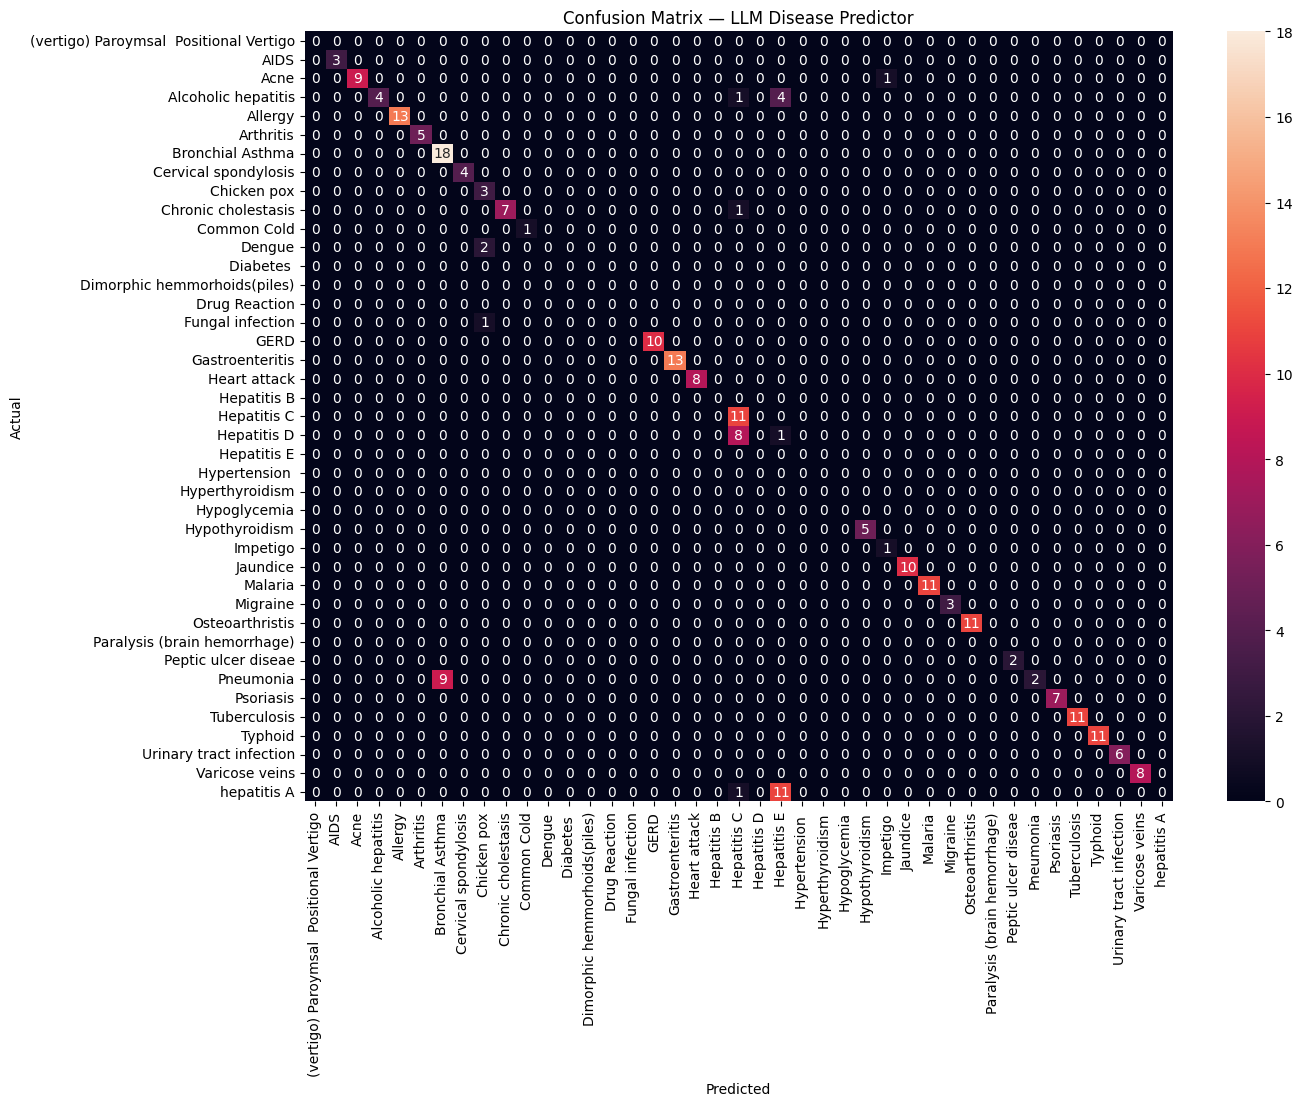

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_true, y_pred, labels=sorted(set(y_true)))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=sorted(set(y_true)),
    yticklabels=sorted(set(y_true))
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — LLM Disease Predictor")
plt.savefig("confusion_matrix.png")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Accuracy: 0.40040650406504064

Classification Report:

                                                                                                                   precision    recall  f1-score   support

                                                                          (vertigo) Paroymsal  Positional Vertigo       0.00      0.00      0.00        10
                                                                                               ABSCESS IN THE EYE       0.00      0.00      0.00         0
                                                                                                             AIDS       1.00      0.23      0.38        13
                                                                              ALS - Amyotrophic Lateral Sclerosis       0.00      0.00      0.00         0
                                                                                                             Acne       1.00      0.90      0.95        10
              

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_